<a href="https://colab.research.google.com/github/AshSama12/Measurements/blob/master/key_point_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXTRACTING DATASET
Dataset extracted to:
/content/GMAS_KEYPOINT_DATASET

DATASET DIRECTORY STRUCTURE
GMAS_KEYPOINT_DATASET/
    README.dataset.txt
    data.yaml
    README.roboflow.txt
    train/
        labels/
            397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt
            358_jpeg.rf.NppraQQt0ufLkpb3CCaQ.txt
            379_jpeg.rf.rbSwwtCkfqOiCY58QPHW.txt
            425_jpeg.rf.MLFZFgfMXLaByHKHizGY.txt
            411_jpeg.rf.fFUJHdtLBmLJyHlXBLCT.txt
            404_jpeg.rf.FYIGErh3xQOv6Wrs31uQ.txt
            407_jpeg.rf.McyUAxxST8DG4Fn5dGGN.txt
            432_jpeg.rf.2bSPWhDWrIjhmEuRGa9I.txt
            378_jpeg.rf.6wjEjKisv1Ypj50911Eg.txt
            363_jpeg.rf.0VbObufhcX7YdranqPJP.txt
            ... (50 files)
        images/
            392_jpeg.rf.yotyCIzhUla7okSAuiZI.jpeg
            405_jpeg.rf.StbN4GWYzS5MFafvEQak.jpeg
            288_jpeg.rf.anmlKFJHXZY6z9SVArmc.jpeg
            291_jpeg.rf.nASEK2HWi02VcXUcrY7L.jpeg
            364_jpeg.rf.tO75hTw5BWkv9EjgA5ZY.jpeg
     

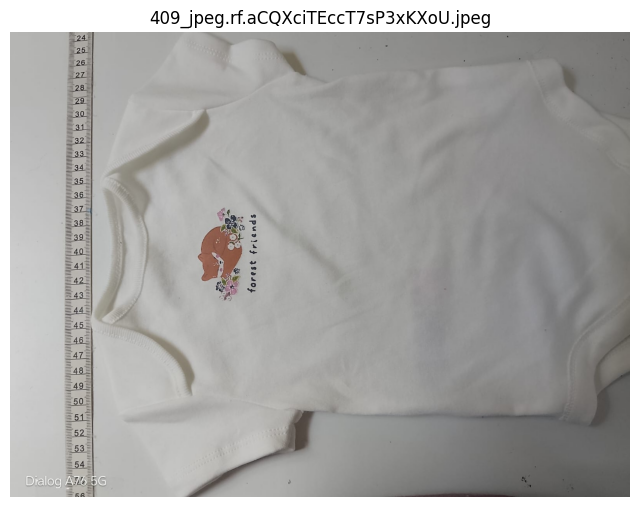

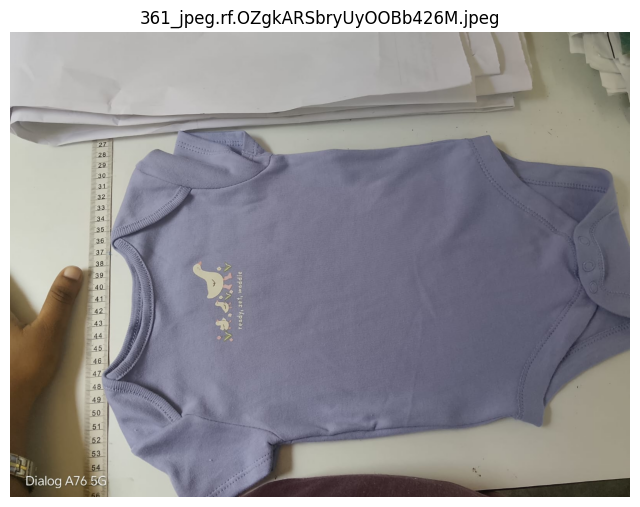

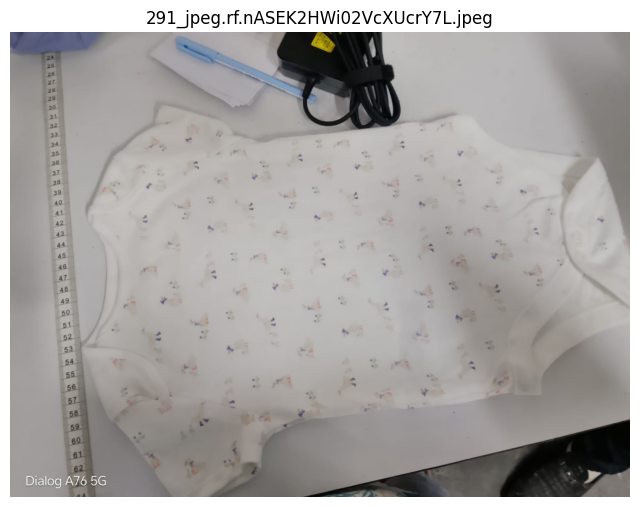

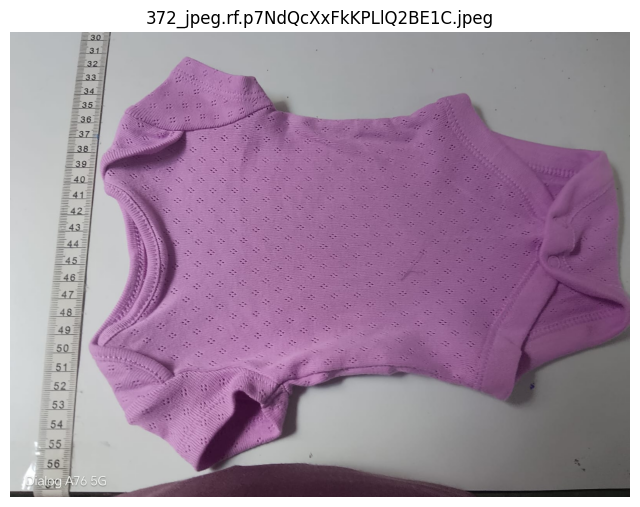

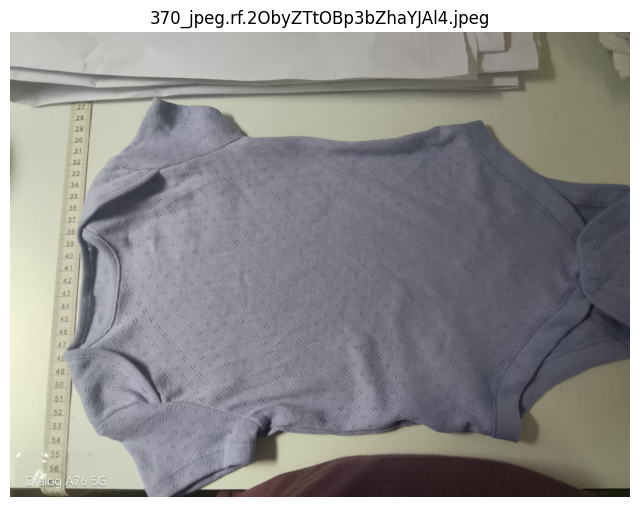

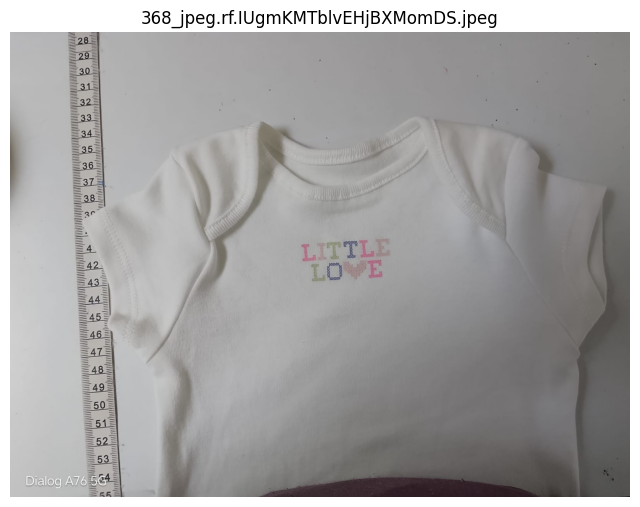


FINAL DATASET REPORT
Total images: 50
Total labels: 52
Matched pairs: 50
Missing labels: 0
Missing images: 2
Keypoints per annotation: [1, 2, 3]

Dataset inspection completed.
DO NOT TRAIN YET.
Send me the complete output and the displayed annotated images.


In [2]:
# ============================================================
# GMAS - KEYPOINT DATASET VALIDATION
# Step 1: Inspect and validate the 50-image dataset
# ============================================================

import os
import zipfile
import glob
import shutil
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Dataset ZIP path
# ------------------------------------------------------------

ZIP_PATH = "/content/GMAS KEYPOINT.yolov8 (1).zip"
EXTRACT_DIR = "/content/GMAS_KEYPOINT_DATASET"

# Remove previous extraction if it exists
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Extract ZIP
# ------------------------------------------------------------

print("=" * 70)
print("EXTRACTING DATASET")
print("=" * 70)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:")
print(EXTRACT_DIR)

# ------------------------------------------------------------
# 3. Print directory structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET DIRECTORY STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

    if len(files) > 10:
        print(f"{indent}    ... ({len(files)} files)")

# ------------------------------------------------------------
# 4. Find YAML files
# ------------------------------------------------------------

yaml_files = []

for ext in ["*.yaml", "*.yml"]:
    yaml_files.extend(
        glob.glob(
            os.path.join(EXTRACT_DIR, "**", ext),
            recursive=True
        )
    )

print("\n" + "=" * 70)
print("YAML FILES")
print("=" * 70)

if yaml_files:
    for yaml_file in yaml_files:
        print(yaml_file)
else:
    print("WARNING: No YAML file found!")

# ------------------------------------------------------------
# 5. Find all images and label files
# ------------------------------------------------------------

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
label_extensions = ["*.txt"]

images = []
labels = []

for ext in image_extensions:
    images.extend(
        glob.glob(
            os.path.join(EXTRACT_DIR, "**", ext),
            recursive=True
        )
    )

for ext in label_extensions:
    labels.extend(
        glob.glob(
            os.path.join(EXTRACT_DIR, "**", ext),
            recursive=True
        )
    )

# Remove possible YAML-related/non-label txt files later if needed
images = sorted(images)
labels = sorted(labels)

print("\n" + "=" * 70)
print("DATASET COUNTS")
print("=" * 70)

print("Total images :", len(images))
print("Total .txt files :", len(labels))

# ------------------------------------------------------------
# 6. Show image examples
# ------------------------------------------------------------

print("\nFirst 10 images:")

for img in images[:10]:
    print(img)

# ------------------------------------------------------------
# 7. Show label examples
# ------------------------------------------------------------

print("\nFirst 10 TXT files:")

for label in labels[:10]:
    print(label)

# ------------------------------------------------------------
# 8. Match images with labels
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMAGE / LABEL MATCHING")
print("=" * 70)

image_stems = {
    Path(img).stem: img
    for img in images
}

label_stems = {
    Path(lbl).stem: lbl
    for lbl in labels
}

missing_labels = []
missing_images = []

for stem in image_stems:
    if stem not in label_stems:
        missing_labels.append(stem)

for stem in label_stems:
    if stem not in image_stems:
        missing_images.append(stem)

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))

if missing_labels:
    print("\nImages without labels:")
    print(missing_labels[:20])

if missing_images:
    print("\nLabels without images:")
    print(missing_images[:20])

# ------------------------------------------------------------
# 9. Inspect annotation format
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ANNOTATION FORMAT INSPECTION")
print("=" * 70)

valid_label_files = []

for label_file in labels:

    # Ignore possible non-label txt files
    try:
        with open(label_file, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except:
        continue

    if len(lines) == 0:
        continue

    valid_label_files.append(label_file)

    print("\nLabel file:")
    print(label_file)

    print("Number of objects:", len(lines))

    for line in lines[:2]:
        values = line.split()

        print("Number of values:", len(values))
        print("First values:", values[:15])

    # Only show first few files
    if len(valid_label_files) >= 5:
        break

# ------------------------------------------------------------
# 10. Determine number of keypoints
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KEYPOINT COUNT ANALYSIS")
print("=" * 70)

keypoint_counts = []
object_counts = []

for label_file in labels:

    try:
        with open(label_file, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except:
        continue

    for line in lines:

        values = line.split()

        # YOLO pose format:
        # class x_center y_center width height
        # followed by keypoints
        #
        # Each keypoint normally has:
        # x y visibility
        #
        # Therefore:
        # keypoint_count = (number_of_values - 5) / 3

        if len(values) >= 8:

            remaining = len(values) - 5

            if remaining % 3 == 0:

                kp_count = remaining // 3
                keypoint_counts.append(kp_count)

            object_counts.append(1)

print("Total annotated objects:", len(object_counts))

if keypoint_counts:

    counter = Counter(keypoint_counts)

    print("\nKeypoint count distribution:")

    for count, frequency in sorted(counter.items()):
        print(
            f"{count} keypoints : "
            f"{frequency} annotations"
        )

else:
    print("WARNING: Could not determine keypoint count.")

# ------------------------------------------------------------
# 11. Check annotation values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ANNOTATION VALUE VALIDATION")
print("=" * 70)

invalid_coordinates = []
invalid_visibility = []

checked_objects = 0

for label_file in labels:

    try:
        with open(label_file, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except:
        continue

    for line_number, line in enumerate(lines):

        values = line.split()

        if len(values) < 8:
            continue

        checked_objects += 1

        try:

            nums = [float(v) for v in values]

            # Class
            class_id = int(nums[0])

            # Bounding box
            bbox = nums[1:5]

            # Check bbox
            for value in bbox:
                if value < 0 or value > 1:
                    invalid_coordinates.append(
                        (label_file, line_number + 1, value)
                    )

            # Keypoints
            keypoints = nums[5:]

            for i in range(0, len(keypoints), 3):

                x = keypoints[i]
                y = keypoints[i + 1]
                visibility = keypoints[i + 2]

                if x < 0 or x > 1:
                    invalid_coordinates.append(
                        (label_file, line_number + 1, x)
                    )

                if y < 0 or y > 1:
                    invalid_coordinates.append(
                        (label_file, line_number + 1, y)
                    )

                if visibility not in [0, 1, 2]:
                    invalid_visibility.append(
                        (label_file, line_number + 1, visibility)
                    )

        except Exception as e:
            print("Error:", label_file, e)

print("Objects checked:", checked_objects)
print("Invalid coordinates:", len(invalid_coordinates))
print("Invalid visibility values:", len(invalid_visibility))

# ------------------------------------------------------------
# 12. Visualize annotated keypoints
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VISUALIZING ANNOTATIONS")
print("=" * 70)

# Match images and labels
matched_pairs = []

for stem in image_stems:

    if stem in label_stems:

        matched_pairs.append(
            (image_stems[stem], label_stems[stem])
        )

print("Matched image-label pairs:", len(matched_pairs))

# Select up to 6 images
random.seed(42)

if len(matched_pairs) > 6:
    selected_pairs = random.sample(matched_pairs, 6)
else:
    selected_pairs = matched_pairs

for img_path, label_path in selected_pairs:

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    plt.figure(figsize=(8, 10))
    plt.imshow(img)

    for line in lines:

        values = line.split()

        if len(values) < 8:
            continue

        values = [float(v) for v in values]

        # Bounding box
        x_center = values[1] * w
        y_center = values[2] * h
        box_w = values[3] * w
        box_h = values[4] * h

        x1 = x_center - box_w / 2
        y1 = y_center - box_h / 2
        x2 = x_center + box_w / 2
        y2 = y_center + box_h / 2

        plt.plot(
            [x1, x2, x2, x1, x1],
            [y1, y1, y2, y2, y1],
            linewidth=1
        )

        # Keypoints
        keypoints = values[5:]

        for i in range(0, len(keypoints), 3):

            x = keypoints[i] * w
            y = keypoints[i + 1] * h
            visibility = keypoints[i + 2]

            # Only draw visible/labeled keypoints
            if visibility > 0:

                plt.scatter(
                    x,
                    y,
                    s=35
                )

                plt.text(
                    x + 5,
                    y + 5,
                    str(i // 3),
                    fontsize=8
                )

    plt.title(Path(img_path).name)
    plt.axis("off")
    plt.show()

# ------------------------------------------------------------
# 13. Final dataset report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET REPORT")
print("=" * 70)

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Matched pairs:", len(matched_pairs))
print("Missing labels:", len(missing_labels))
print("Missing images:", len(missing_images))

if keypoint_counts:
    print(
        "Keypoints per annotation:",
        sorted(set(keypoint_counts))
    )

print("\nDataset inspection completed.")
print("DO NOT TRAIN YET.")
print("Send me the complete output and the displayed annotated images.")

In [5]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 6.2 MB/s eta 0:00:00


In [8]:
!mkdir -p /content/GMAS_KEYPOINT_DATASET/valid/images
!mkdir -p /content/GMAS_KEYPOINT_DATASET/valid/labels


In [9]:
import os, random, shutil

train_img_dir = "/content/GMAS_KEYPOINT_DATASET/train/images"
train_lbl_dir = "/content/GMAS_KEYPOINT_DATASET/train/labels"
val_img_dir = "/content/GMAS_KEYPOINT_DATASET/valid/images"
val_lbl_dir = "/content/GMAS_KEYPOINT_DATASET/valid/labels"

os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

images = os.listdir(train_img_dir)
random.seed(42)
val_images = random.sample(images, 10)  # pick 10 for validation

for img in val_images:
    stem = os.path.splitext(img)[0]
    shutil.move(os.path.join(train_img_dir, img), val_img_dir)
    lbl_file = stem + ".txt"
    if os.path.exists(os.path.join(train_lbl_dir, lbl_file)):
        shutil.move(os.path.join(train_lbl_dir, lbl_file), val_lbl_dir)


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n-pose.pt")

results = model.train(
    data="/content/GMAS_KEYPOINT_DATASET/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

metrics = model.val()
model.predict("/content/GMAS_KEYPOINT_DATASET/valid/images", save=True)


Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GMAS_KEYPOINT_DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64,

RuntimeError: No valid images found in /content/GMAS_KEYPOINT_DATASET/train/labels.cache.
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/288_jpeg.rf.anmlKFJHXZY6z9SVArmc.jpeg: ignoring corrupt image/label: labels require 62 columns each
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/291_jpeg.rf.nASEK2HWi02VcXUcrY7L.jpeg: ignoring corrupt image/label: labels require 62 columns each
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/292_jpeg.rf.RXkuG0RslCzpUNHjKLr1.jpeg: ignoring corrupt image/label: labels require 62 columns each
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/295_jpeg.rf.B7olIjVy9H2jCwjNl3dC.jpeg: ignoring corrupt image/label: labels require 62 columns each
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/296_jpeg.rf.SBgaPBbFSqxVkFtnsKth.jpeg: ignoring corrupt image/label: labels require 62 columns each
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/362_jpeg.rf.lQ

In [12]:
import glob

label_files = glob.glob("/content/GMAS_KEYPOINT_DATASET/train/labels/*.txt")

for lf in label_files[:5]:
    with open(lf) as f:
        for line in f.readlines():
            values = line.strip().split()
            print(lf, "->", len(values), "columns")


/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5GkrNhC0wx2zRmCgic.txt -> 5 columns
/content/GMAS_KEYPOINT_DATASET/train/labels/397_jpeg.rf.pJ5G

In [13]:
import glob

label_files = glob.glob("/content/GMAS_KEYPOINT_DATASET/train/labels/*.txt")

for lf in label_files:
    new_lines = []
    with open(lf) as f:
        for line in f.readlines():
            values = line.strip().split()
            if len(values) == 5:
                # Add 19 keypoints (x, y, vis) all set to 0
                kp_placeholder = ["0", "0", "0"] * 19
                new_line = values + kp_placeholder
                new_lines.append(" ".join(new_line))
            else:
                new_lines.append(line.strip())
    with open(lf, "w") as f:
        f.write("\n".join(new_lines))


In [14]:
import glob

label_files = glob.glob("/content/GMAS_KEYPOINT_DATASET/train/labels/*.txt")

for lf in label_files:
    new_lines = []
    with open(lf) as f:
        for line in f.readlines():
            values = line.strip().split()
            if len(values) == 5:
                # Add 19 keypoints (x, y, vis) all set to 0
                kp_placeholder = ["0", "0", "0"] * 19
                new_line = values + kp_placeholder
                new_lines.append(" ".join(new_line))
            else:
                new_lines.append(line.strip())
    with open(lf, "w") as f:
        f.write("\n".join(new_lines))


In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n-pose.pt")

results = model.train(
    data="/content/GMAS_KEYPOINT_DATASET/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

metrics = model.val()
model.predict("/content/GMAS_KEYPOINT_DATASET/valid/images", save=True)


Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GMAS_KEYPOINT_DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64,

RuntimeError: No valid images found in /content/GMAS_KEYPOINT_DATASET/train/labels.cache.
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/288_jpeg.rf.anmlKFJHXZY6z9SVArmc.jpeg: ignoring corrupt image/label: Label class 17 exceeds dataset class count 1. Possible class labels are 0-0
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/291_jpeg.rf.nASEK2HWi02VcXUcrY7L.jpeg: ignoring corrupt image/label: Label class 18 exceeds dataset class count 1. Possible class labels are 0-0
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/292_jpeg.rf.RXkuG0RslCzpUNHjKLr1.jpeg: ignoring corrupt image/label: Label class 18 exceeds dataset class count 1. Possible class labels are 0-0
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/295_jpeg.rf.B7olIjVy9H2jCwjNl3dC.jpeg: ignoring corrupt image/label: Label class 18 exceeds dataset class count 1. Possible class labels are 0-0
  [34m[1mtrain: [0m/content/GMAS_KEYPOINT_DATASET/train/images/

In [16]:
import glob

label_files = glob.glob("/content/GMAS_KEYPOINT_DATASET/train/labels/*.txt")

for lf in label_files:
    new_lines = []
    with open(lf) as f:
        for line in f.readlines():
            values = line.strip().split()
            if len(values) >= 5:
                # Force class ID to 0
                values[0] = "0"
                new_lines.append(" ".join(values))
    with open(lf, "w") as f:
        f.write("\n".join(new_lines))


In [18]:
import glob
import os
import shutil
from ultralytics import YOLO

# Define the label directories
train_label_dir = "/content/GMAS_KEYPOINT_DATASET/train/labels"
val_label_dir = "/content/GMAS_KEYPOINT_DATASET/valid/labels"

# List of label directories to process
label_dirs = [train_label_dir, val_label_dir]

EXPECTED_KEYPOINTS = 19

for current_label_dir in label_dirs:
    # Get all .txt files, excluding README files
    label_files = [f for f in glob.glob(os.path.join(current_label_dir, "*.txt")) if "README" not in os.path.basename(f)]

    for lf in label_files:
        new_lines = []
        with open(lf, "r") as f:
            for line in f.readlines():
                values = line.strip().split()

                if len(values) < 5:  # Minimum for class + bbox
                    if len(values) > 0: # Warn if line has content but is too short
                        print(f"Warning: Skipping invalid line (too few values) in {lf}: {' '.join(values[:5])}...")
                    continue

                # Force class ID to 0
                class_id = "0"

                # Extract bounding box values
                bbox_values = values[1:5]

                # Extract existing keypoint values
                original_kp_values = values[5:]

                # Prepare new keypoint values, padding with '0's if necessary
                target_kp_values = ["0"] * (EXPECTED_KEYPOINTS * 3)
                for i in range(min(len(original_kp_values), len(target_kp_values))):
                    target_kp_values[i] = original_kp_values[i]

                # Combine all parts into the new line
                new_line_parts = [class_id] + bbox_values + target_kp_values
                new_lines.append(" ".join(new_line_parts))

        with open(lf, "w") as f:
            f.write("\n".join(new_lines))

# Remove existing cache files to force YOLOv8 to re-read updated labels
for cache_file in glob.glob("/content/GMAS_KEYPOINT_DATASET/**/labels.cache", recursive=True):
    os.remove(cache_file)
    print(f"Removed cache file: {cache_file}")


model = YOLO("yolov8n-pose.pt")

results = model.train(
    data="/content/GMAS_KEYPOINT_DATASET/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

metrics = model.val()
model.predict("/content/GMAS_KEYPOINT_DATASET/valid/images", save=True)

Removed cache file: /content/GMAS_KEYPOINT_DATASET/train/labels.cache
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GMAS_KEYPOINT_DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'body_suit'}
 obb: None
 orig_img: array([[[199, 184, 188],
         [199, 184, 188],
         [199, 184, 188],
         ...,
         [ 52,  54,  64],
         [ 54,  57,  65],
         [ 66,  69,  77]],
 
        [[199, 184, 188],
         [199, 184, 188],
         [199, 184, 188],
         ...,
         [ 61,  63,  74],
         [ 58,  60,  70],
         [ 60,  62,  72]],
 
        [[199, 184, 188],
         [199, 184, 188],
         [199, 184, 188],
         ...,
         [ 59,  59,  75],
         [ 58,  58,  74],
         [ 59,  59,  75]],
 
        ...,
 
        [[ 40,  51,  59],
         [ 40,  51,  59],
         [ 39,  50,  58],
         ...,
         [ 28,  32,  33],
         [ 29,  33,  34],
         [ 29,  33,  34]],
 
        [[ 39,  50,  58],
         [ 40,  51,  59],
   

In [19]:
import gradio as gr
from ultralytics import YOLO
import cv2


model = YOLO("/content/runs/pose/train-6/weights/best.pt")


keypoint_names = [
    "Crotch", "L.AH", "L.HP", "L.LOE", "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

def predict(image):
    results = model.predict(source=image, save=False, conf=0.25)
    annotated_img = results[0].plot()  # YOLO built-in plotting
    return annotated_img

# Gradio interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="filepath"),
    outputs=gr.Image(type="numpy"),
    title="GMAS Keypoint Detection",
    description="Upload an image to see detected keypoints with names."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de3de3d425cb9ea8e2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
import math
import cv2
from ultralytics import YOLO

# Load trained model
model = YOLO("/content/runs/pose/train-6/weights/best.pt")

# Keypoint names (must match your data.yaml order)
keypoint_names = [
    "Crotch", "L.AH", "L.HP", "L.LOE", "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def compute_measurements(image_path):
    # Run inference
    results = model.predict(image_path, conf=0.25)
    img = cv2.imread(image_path)

    # Get keypoints (already in pixel coordinates)
    kp = results[0].keypoints.xy[0].cpu().numpy()  # shape (19,2)
    kp_pixels = {name: (kp[i][0], kp[i][1]) for i, name in enumerate(keypoint_names)}

    # Compute measurements
    measurements = {
        "Chest": distance(kp_pixels["L.AH"], kp_pixels["R.AH"]),
        "Hip": distance(kp_pixels["L.HP"], kp_pixels["R.HP"]),
        "Side seam (L)": distance(kp_pixels["L.AH"], kp_pixels["L.SSE"]),
        "Side seam (R)": distance(kp_pixels["R.AH"], kp_pixels["R.SSE"]),
        "Length (L)": distance(kp_pixels["L.SNP"], kp_pixels["Crotch"]),
        "Length (R)": distance(kp_pixels["R.SNP"], kp_pixels["Crotch"]),
        "Neck seam": distance(kp_pixels["L.SNP"], kp_pixels["R.SNP"]),
        "Sleeve length (L)": distance(kp_pixels["L.SP"], kp_pixels["L.SOS"]),
        "Sleeve length (R)": distance(kp_pixels["R.SP"], kp_pixels["R.SOS"]),
        "Leg opening (L)": distance(kp_pixels["L.SSE"], kp_pixels["L.LOE"]),
        "Leg opening (R)": distance(kp_pixels["R.SSE"], kp_pixels["R.LOE"]),
        "Sleeve opening (L)": distance(kp_pixels["L.SOS"], kp_pixels["L.SOE"]),
        "Sleeve opening (R)": distance(kp_pixels["R.SOS"], kp_pixels["R.SOE"]),
    }

    return measurements

# Example usage
measures = compute_measurements("/content/GMAS_KEYPOINT_DATASET/valid/images/288_jpeg.rf.anmlKFJHXZY6z9SVArmc.jpeg")
print(measures)


FileNotFoundError: /content/GMAS_KEYPOINT_DATASET/valid/images/288_jpeg.rf.anmlKFJHXZY6z9SVArmc.jpeg does not exist

In [22]:
import os
val_img_dir = "/content/GMAS_KEYPOINT_DATASET/valid/images"
print(os.listdir(val_img_dir)[:5])  # show first 5 files


['405_jpeg.rf.StbN4GWYzS5MFafvEQak.jpeg', '360_jpeg.rf.CGH7NEDLdJU591MOcZls.jpeg', '361_jpeg.rf.OZgkARSbryUyOOBb426M.jpeg', '396_jpeg.rf.spSGvClv44vSmOGeVljc.jpeg', '358_jpeg.rf.NppraQQt0ufLkpb3CCaQ.jpeg']


In [24]:
import math
import cv2
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/content/runs/pose/train-6/weights/best.pt")

# Keypoint names (must match your data.yaml order)
keypoint_names = [
    "Crotch", "L.AH", "L.HP", "L.LOE", "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def compute_measurements(image_path):
    # Run inference
    results = model.predict(image_path, conf=0.25)

    # Check if any detections were made and if keypoints are available
    if not results or not hasattr(results[0], 'keypoints') or results[0].keypoints.xy.shape[0] == 0:
        print(f"No keypoints detected for {image_path}.")
        return {}

    # Get keypoints (already in pixel coordinates)
    kp = results[0].keypoints.xy[0].cpu().numpy()  # shape (19,2)
    kp_pixels = {name: (kp[i][0], kp[i][1]) for i, name in enumerate(keypoint_names)}

    # Compute measurements
    measurements = {
        "Chest": distance(kp_pixels["L.AH"], kp_pixels["R.AH"]),
        "Hip": distance(kp_pixels["L.HP"], kp_pixels["R.HP"]),
        "Side seam (L)": distance(kp_pixels["L.AH"], kp_pixels["L.SSE"]),
        "Side seam (R)": distance(kp_pixels["R.AH"], kp_pixels["R.SSE"]),
        "Length (L)": distance(kp_pixels["L.SNP"], kp_pixels["Crotch"]),
        "Length (R)": distance(kp_pixels["R.SNP"], kp_pixels["Crotch"]),
        "Neck seam": distance(kp_pixels["L.SNP"], kp_pixels["R.SNP"]),
        "Sleeve length (L)": distance(kp_pixels["L.SP"], kp_pixels["L.SOS"]),
        "Sleeve length (R)": distance(kp_pixels["R.SP"], kp_pixels["R.SOS"]),
        "Leg opening (L)": distance(kp_pixels["L.SSE"], kp_pixels["L.LOE"]),
        "Leg opening (R)": distance(kp_pixels["R.SSE"], kp_pixels["R.LOE"]),
        "Sleeve opening (L)": distance(kp_pixels["L.SOS"], kp_pixels["L.SOE"]),
        "Sleeve opening (R)": distance(kp_pixels["R.SOS"], kp_pixels["R.SOE"]),
    }

    return measurements

# Example usage with one of your valid images
test_image = "/content/GMAS_KEYPOINT_DATASET/valid/images/405_jpeg.rf.StbN4GWYzS5MFafvEQak.jpeg"
measures = compute_measurements(test_image)
print(measures)



image 1/1 /content/GMAS_KEYPOINT_DATASET/valid/images/405_jpeg.rf.StbN4GWYzS5MFafvEQak.jpeg: 640x480 (no detections), 8.1ms
Speed: 2.9ms preprocess, 8.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
No keypoints detected for /content/GMAS_KEYPOINT_DATASET/valid/images/405_jpeg.rf.StbN4GWYzS5MFafvEQak.jpeg.
{}


In [25]:
import math
import cv2
import gradio as gr
from ultralytics import YOLO

# Load trained model
model = YOLO("/content/runs/pose/train-6/weights/best.pt")

# Keypoint names (must match your data.yaml order)
keypoint_names = [
    "Crotch", "L.AH", "L.HP", "L.LOE", "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def analyze_image(image):
    # Run inference
    results = model.predict(image, conf=0.25)

    if not results or not hasattr(results[0], 'keypoints') or results[0].keypoints.xy.shape[0] == 0:
        return image, {"Error": "No keypoints detected"}

    # Get keypoints
    kp = results[0].keypoints.xy[0].cpu().numpy()
    kp_pixels = {name: (kp[i][0], kp[i][1]) for i, name in enumerate(keypoint_names)}

    # Compute measurements
    measurements = {
        "Chest": distance(kp_pixels["L.AH"], kp_pixels["R.AH"]),
        "Hip": distance(kp_pixels["L.HP"], kp_pixels["R.HP"]),
        "Side seam (L)": distance(kp_pixels["L.AH"], kp_pixels["L.SSE"]),
        "Side seam (R)": distance(kp_pixels["R.AH"], kp_pixels["R.SSE"]),
        "Length (L)": distance(kp_pixels["L.SNP"], kp_pixels["Crotch"]),
        "Length (R)": distance(kp_pixels["R.SNP"], kp_pixels["Crotch"]),
        "Neck seam": distance(kp_pixels["L.SNP"], kp_pixels["R.SNP"]),
        "Sleeve length (L)": distance(kp_pixels["L.SP"], kp_pixels["L.SOS"]),
        "Sleeve length (R)": distance(kp_pixels["R.SP"], kp_pixels["R.SOS"]),
        "Leg opening (L)": distance(kp_pixels["L.SSE"], kp_pixels["L.LOE"]),
        "Leg opening (R)": distance(kp_pixels["R.SSE"], kp_pixels["R.LOE"]),
        "Sleeve opening (L)": distance(kp_pixels["L.SOS"], kp_pixels["L.SOE"]),
        "Sleeve opening (R)": distance(kp_pixels["R.SOS"], kp_pixels["R.SOE"]),
    }

    # Annotated image
    annotated_img = results[0].plot()

    return annotated_img, measurements

# Gradio interface
demo = gr.Interface(
    fn=analyze_image,
    inputs=gr.Image(type="filepath"),
    outputs=[gr.Image(type="numpy"), gr.Label(num_top_classes=20)],
    title="Garment Measurement with Keypoints",
    description="Upload an image to see detected keypoints and garment measurements."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://215fbd4076ab7732b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
import math
import cv2
import gradio as gr
from ultralytics import YOLO

model = YOLO("/content/runs/pose/train-6/weights/best.pt")

keypoint_names = [
    "Crotch", "L.AH", "L.HP", "L.LOE", "L.NEP", "L.SNP", "L.SOE", "L.SOS", "L.SP", "L.SSE",
    "R.AH", "R.HP", "R.LOE", "R.NEP", "R.SNP", "R.SOE", "R.SOS", "R.SP", "R.SSE"
]

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def analyze_image(image_path):
    results = model.predict(image_path, conf=0.25)

    if not results or not hasattr(results[0], 'keypoints') or results[0].keypoints.xy.shape[0] == 0:
        return None, {"Error": "No keypoints detected"}

    kp = results[0].keypoints.xy[0].cpu().numpy()
    kp_pixels = {name: (kp[i][0], kp[i][1]) for i, name in enumerate(keypoint_names)}

    measurements = {
        "Chest": distance(kp_pixels["L.AH"], kp_pixels["R.AH"]),
        "Hip": distance(kp_pixels["L.HP"], kp_pixels["R.HP"]),
        "Side seam (L)": distance(kp_pixels["L.AH"], kp_pixels["L.SSE"]),
        "Side seam (R)": distance(kp_pixels["R.AH"], kp_pixels["R.SSE"]),
        "Length (L)": distance(kp_pixels["L.SNP"], kp_pixels["Crotch"]),
        "Length (R)": distance(kp_pixels["R.SNP"], kp_pixels["Crotch"]),
        "Neck seam": distance(kp_pixels["L.SNP"], kp_pixels["R.SNP"]),
        "Sleeve length (L)": distance(kp_pixels["L.SP"], kp_pixels["L.SOS"]),
        "Sleeve length (R)": distance(kp_pixels["R.SP"], kp_pixels["R.SOS"]),
        "Leg opening (L)": distance(kp_pixels["L.SSE"], kp_pixels["L.LOE"]),
        "Leg opening (R)": distance(kp_pixels["R.SSE"], kp_pixels["R.LOE"]),
        "Sleeve opening (L)": distance(kp_pixels["L.SOS"], kp_pixels["L.SOE"]),
        "Sleeve opening (R)": distance(kp_pixels["R.SOS"], kp_pixels["R.SOE"]),
    }

    annotated_img = results[0].plot()
    return annotated_img, measurements

demo = gr.Interface(
    fn=analyze_image,
    inputs=gr.Image(type="filepath", label="Upload garment image"),
    outputs=[
        gr.Image(type="numpy", label="Annotated keypoints"),
        gr.JSON(label="Measurements (pixels)")
    ],
    title="Garment Measurement with Keypoints",
    description="Upload an image to see detected keypoints and garment measurements."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8bd986460b23a8105.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
